### Basic Rule based Scoring

In [3]:
import pandas as pd
import numpy as np
import re

In [4]:
file_path="AutoEIT Sample Transcriptions for Scoring.xlsx"
xls = pd.ExcelFile(file_path)
sheet_names = xls.sheet_names
print(sheet_names)

['Info', '38001-1A', '38002-2A', '38004-2A', '38006-2A']


In [5]:
df=pd.read_excel(xls,sheet_name=sheet_names[1])
df.head()

,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo (7),Quiero cortarme el pelo,NaN
1,2,El libro está en la mesa (7),El libro está en la mesa,NaN
2,3,El carro lo tiene Pedro (8),El carro lo tiene Pedro,NaN
3,4,El se ducha cada mañana (9),El se ducha cada mañana,NaN
4,5,¿Qué dice usted que va a hacer hoy? (9),Que dices ustedes se que van a hacer hoy?,NaN


In [6]:
def preprocess(text):
    if pd.isna(text):
        return "";
    text=text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text=re.sub(r'[^\w\s]','',text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


In [7]:
df["clean_stimulus"]=df["Stimulus"].apply(preprocess)
df["clean_original"]=df["Transcription Rater 1"].apply(preprocess)
df.head()

,Sentence,Stimulus,Transcription Rater 1,Score,clean_stimulus,clean_original
0,1,Quiero cortarme el pelo (7),Quiero cortarme el pelo,NaN,quiero cortarme el pelo 7,quiero cortarme el pelo
1,2,El libro está en la mesa (7),El libro está en la mesa,NaN,el libro está en la mesa 7,el libro está en la mesa
2,3,El carro lo tiene Pedro (8),El carro lo tiene Pedro,NaN,el carro lo tiene pedro 8,el carro lo tiene pedro
3,4,El se ducha cada mañana (9),El se ducha cada mañana,NaN,el se ducha cada mañana 9,el se ducha cada mañana
4,5,¿Qué dice usted que va a hacer hoy? (9),Que dices ustedes se que van a hacer hoy?,NaN,qué dice usted que va a hacer hoy 9,que dices ustedes se que van a hacer hoy


In [8]:
def word_overlap(s1, s2):
    set1 = set(s1.split())
    set2 = set(s2.split())
    if len(set1) == 0:
        return 0
    return len(set1 & set2) / len(set1)

In [12]:
overlap_scores = []
for _, row in df.iterrows():
    stimulus = row['clean_stimulus']
    response = row['clean_original']
    overlap_scores.append(word_overlap(stimulus, response))

avg_overlap = np.mean(overlap_scores)

In [13]:
print(avg_overlap)

0.6817080142080142


In [14]:
def score(stimulus,response):
    overlap=word_overlap(stimulus,response)
    if(overlap>0.9):
        return 4
    elif(overlap>0.75):
        return 3
    elif(overlap>0.5):
        return 2
    elif(overlap>0.3):
        return 1
    else:
        return 0
        

In [15]:
df["Score"] = df.apply(
    lambda row: score(row["clean_stimulus"], row["clean_original"]), axis=1
)
df.head(50)

,Sentence,Stimulus,Transcription Rater 1,Score,clean_stimulus,clean_original
0,1,Quiero cortarme el pelo (7),Quiero cortarme el pelo,3,quiero cortarme el pelo 7,quiero cortarme el pelo
1,2,El libro está en la mesa (7),El libro está en la mesa,3,el libro está en la mesa 7,el libro está en la mesa
2,3,El carro lo tiene Pedro (8),El carro lo tiene Pedro,3,el carro lo tiene pedro 8,el carro lo tiene pedro
3,4,El se ducha cada mañana (9),El se ducha cada mañana,3,el se ducha cada mañana 9,el se ducha cada mañana
4,5,¿Qué dice usted que va a hacer hoy? (9),Que dices ustedes se que van a hacer hoy?,1,qué dice usted que va a hacer hoy 9,que dices ustedes se que van a hacer hoy
5,6,Dudo que sepa manejar muy bien (10),Dudo que sepa manajar bien,2,dudo que sepa manejar muy bien 10,dudo que sepa manajar bien
6,7,Las calles de esta ciudad son muy anchas (11),Las calles de esta cuidad son muy anchas,3,las calles de esta ciudad son muy anchas 11,las calles de esta cuidad son muy anchas
7,8,Puede que llueva mañana todo el día (12),Puede que lleva mañana todo el día,2,puede que llueva mañana todo el día 12,puede que lleva mañana todo el día
8,9,Las casas son muy bonitas pero caras (12),Las casas son muy bonitas pero muy cadas,2,las casas son muy bonitas pero caras 12,las casas son muy bonitas pero muy cadas
9,10,Me gustan las películas que acaban bien (12),Me gustan las peliculas que acaban bien,2,me gustan las películas que acaban bien 12,me gustan las peliculas que acaban bien


In [18]:
df.drop("Predicted_Score", axis=1, inplace=True)

In [16]:
df.head(30)

,Sentence,Stimulus,Transcription Rater 1,Score,clean_stimulus,clean_original
0,1,Quiero cortarme el pelo (7),Quiero cortarme el pelo,3,quiero cortarme el pelo 7,quiero cortarme el pelo
1,2,El libro está en la mesa (7),El libro está en la mesa,3,el libro está en la mesa 7,el libro está en la mesa
2,3,El carro lo tiene Pedro (8),El carro lo tiene Pedro,3,el carro lo tiene pedro 8,el carro lo tiene pedro
3,4,El se ducha cada mañana (9),El se ducha cada mañana,3,el se ducha cada mañana 9,el se ducha cada mañana
4,5,¿Qué dice usted que va a hacer hoy? (9),Que dices ustedes se que van a hacer hoy?,1,qué dice usted que va a hacer hoy 9,que dices ustedes se que van a hacer hoy
5,6,Dudo que sepa manejar muy bien (10),Dudo que sepa manajar bien,2,dudo que sepa manejar muy bien 10,dudo que sepa manajar bien
6,7,Las calles de esta ciudad son muy anchas (11),Las calles de esta cuidad son muy anchas,3,las calles de esta ciudad son muy anchas 11,las calles de esta cuidad son muy anchas
7,8,Puede que llueva mañana todo el día (12),Puede que lleva mañana todo el día,2,puede que llueva mañana todo el día 12,puede que lleva mañana todo el día
8,9,Las casas son muy bonitas pero caras (12),Las casas son muy bonitas pero muy cadas,2,las casas son muy bonitas pero caras 12,las casas son muy bonitas pero muy cadas
9,10,Me gustan las películas que acaban bien (12),Me gustan las peliculas que acaban bien,2,me gustan las películas que acaban bien 12,me gustan las peliculas que acaban bien


In [18]:
df.to_excel("basic_score.xlsx", index=False)

### Rule Based+ML(Semantic) based Scoring

In [17]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [19]:
model=SentenceTransformer('all-MiniLM-L6-v2')

C:\Users\Shruti Sachan\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [20]:
def semantic(s1,s2):
    emb1=model.encode(s1)
    emb2=model.encode(s2)
    sim=cosine_similarity([emb1],[emb2])[0][0]
    return sim

In [23]:
semantic_scores = []
for _, row in df.iterrows():
    stimulus = row['clean_stimulus']
    response = row['clean_original']
    semantic_scores.append(semantic(stimulus, response))
avg_semantic = np.mean(semantic_scores)

In [24]:
print(avg_semantic)

0.8731499


In [37]:
from difflib import SequenceMatcher
def edit_sim(s1,s2):
    return SequenceMatcher(None,s1,s2).ratio()

In [38]:
def missing_word(s1,s2):
    word1=set(s1.split())
    word2=set(s2.split())
    missing=len(word1-word2)
    return missing/len(word1)

In [39]:
def get_ngrams(text, n):
    words = text.split()
    return [" ".join(words[i:i+n]) for i in range(len(words)-n+1)]

In [40]:
def ngram_overlap(s1, s2, n=2):
    ngrams1 = set(get_ngrams(s1, n))
    ngrams2 = set(get_ngrams(s2, n))
    if len(ngrams1) == 0:
        return 0
    return len(ngrams1 & ngrams2) / len(ngrams1)

In [41]:
def length_ratio(s1, s2):
    if len(s1.split()) == 0:
        return 0
    return len(s2.split()) / len(s1.split())

In [42]:
def hybrid_score(stimulus, response):
    overlap = word_overlap(stimulus, response)
    semantic_sim = semantic(stimulus, response)
    length = length_ratio(stimulus, response)
    match = edit_sim(stimulus, response)
    bigram_score = ngram_overlap(stimulus, response, n=2)
    final = (
        0.2 * overlap +
        0.25 * semantic_sim +
        0.15 * length +
        0.2 * match +
        0.2 * bigram_score
    )
    if length < 0.6:
        final *= 0.75
    if missing_word(stimulus, response) > 0.4:
        final *= 0.75
    if semantic_sim > 0.9 and overlap > 0.85:
        return 4
    if final > 0.85:
        return 4
    elif final > 0.7:
        return 3
    elif final > 0.5:
        return 2
    elif final > 0.3:
        return 1
    else:
        return 0

In [43]:
hybrid_scores = []

for s, o in zip(semantic_scores, overlap_scores):
    hybrid = 0.7 * s + 0.3 * o
    hybrid_scores.append(hybrid)

In [44]:
print(hybrid_scores)

[0.8921050870418548, 0.9152701531137738, 0.9143821120262146, 0.8961109161376952, 0.6866336305936177, 0.6830997450011116, 0.8472437461217244, 0.8263975262641906, 0.854597771167755, 0.8355560719966888, 0.7837596038977305, 0.8940916140874227, 0.8111361908912658, 0.7888138115406036, 0.87432013352712, 0.8231494832038879, 0.7221153783798218, 0.7754296779632568, 0.6474935483932495, 0.8377903017130764, 0.7928681384433398, 0.8654126560688018, 0.8672894651239568, 0.6963558197021484, 0.6496565927158702, 0.8642405247688293, 0.9188565254211425, 0.7663486632433805, 0.8844990643171163, 0.8564962343736128]


In [45]:
import numpy as np
avg_hybrid = np.mean(hybrid_scores)
print(f"Average Hybrid Score: {avg_hybrid:.2f}")

Average Hybrid Score: 0.82


Improvement Score(avg_overlap vs avg_hybrid)

In [46]:
print(avg_hybrid-avg_overlap)

0.1340093253666611


In [47]:
s = df.loc[0, 'clean_stimulus']
r = df.loc[0, 'clean_original']
scores = []
for _ in range(5):
    scores.append(hybrid_score(s, r))
import numpy as np
print("Scores:", scores)
print("Variance:", np.var(scores))

Scores: [4, 4, 4, 4, 4]
Variance: 0.0


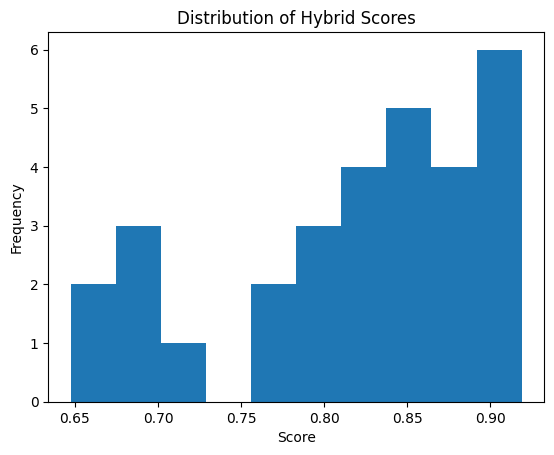

In [48]:
import matplotlib.pyplot as plt
plt.hist(hybrid_scores, bins=10)
plt.title("Distribution of Hybrid Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

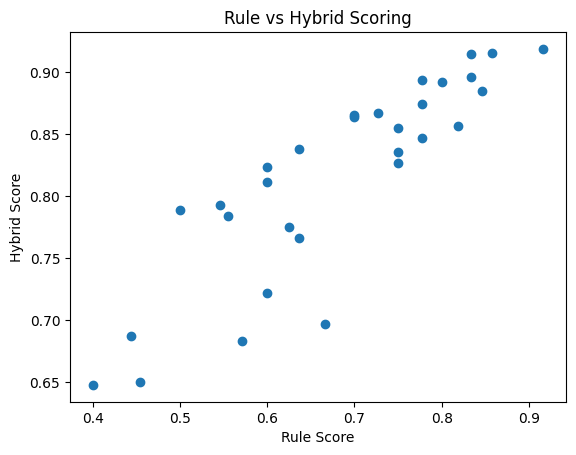

In [49]:
plt.scatter(overlap_scores, hybrid_scores)
plt.xlabel("Rule Score")
plt.ylabel("Hybrid Score")
plt.title("Rule vs Hybrid Scoring")
plt.show()

In [57]:
df["Hybrid_Score"] = df.apply(
    lambda row: hybrid_score(row["clean_stimulus"], row["clean_original"]), axis=1
)

In [58]:
df[["Stimulus", "Transcription Rater 1", "Score", "Hybrid_Score"]].head(10)

,Stimulus,Transcription Rater 1,Score,Hybrid_Score
0,Quiero cortarme el pelo (7),Quiero cortarme el pelo,3,4
1,El libro está en la mesa (7),El libro está en la mesa,3,4
2,El carro lo tiene Pedro (8),El carro lo tiene Pedro,3,4
3,El se ducha cada mañana (9),El se ducha cada mañana,3,4
4,¿Qué dice usted que va a hacer hoy? (9),Que dices ustedes se que van a hacer hoy?,1,1
5,Dudo que sepa manejar muy bien (10),Dudo que sepa manajar bien,2,1
6,Las calles de esta ciudad son muy anchas (11),Las calles de esta cuidad son muy anchas,3,3
7,Puede que llueva mañana todo el día (12),Puede que lleva mañana todo el día,2,3
8,Las casas son muy bonitas pero caras (12),Las casas son muy bonitas pero muy cadas,2,3
9,Me gustan las películas que acaban bien (12),Me gustan las peliculas que acaban bien,2,3


In [59]:
df.head(30)

,Sentence,Stimulus,Transcription Rater 1,Score,clean_stimulus,clean_original,Hybrid_Score
0,1,Quiero cortarme el pelo (7),Quiero cortarme el pelo,3,quiero cortarme el pelo 7,quiero cortarme el pelo,4
1,2,El libro está en la mesa (7),El libro está en la mesa,3,el libro está en la mesa 7,el libro está en la mesa,4
2,3,El carro lo tiene Pedro (8),El carro lo tiene Pedro,3,el carro lo tiene pedro 8,el carro lo tiene pedro,4
3,4,El se ducha cada mañana (9),El se ducha cada mañana,3,el se ducha cada mañana 9,el se ducha cada mañana,4
4,5,¿Qué dice usted que va a hacer hoy? (9),Que dices ustedes se que van a hacer hoy?,1,qué dice usted que va a hacer hoy 9,que dices ustedes se que van a hacer hoy,1
5,6,Dudo que sepa manejar muy bien (10),Dudo que sepa manajar bien,2,dudo que sepa manejar muy bien 10,dudo que sepa manajar bien,1
6,7,Las calles de esta ciudad son muy anchas (11),Las calles de esta cuidad son muy anchas,3,las calles de esta ciudad son muy anchas 11,las calles de esta cuidad son muy anchas,3
7,8,Puede que llueva mañana todo el día (12),Puede que lleva mañana todo el día,2,puede que llueva mañana todo el día 12,puede que lleva mañana todo el día,3
8,9,Las casas son muy bonitas pero caras (12),Las casas son muy bonitas pero muy cadas,2,las casas son muy bonitas pero caras 12,las casas son muy bonitas pero muy cadas,3
9,10,Me gustan las películas que acaban bien (12),Me gustan las peliculas que acaban bien,2,me gustan las películas que acaban bien 12,me gustan las peliculas que acaban bien,3


In [32]:
!pip install xlsxwriter

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import sys
!"{sys.executable}" -m pip install xlsxwriter

  Using cached xlsxwriter-3.2.9-py3-none-any.whl.metadata (2.7 kB)
Using cached xlsxwriter-3.2.9-py3-none-any.whl (175 kB)



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Users\Shruti Sachan\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [60]:
print(df.columns)

Index(['Sentence', 'Stimulus', 'Transcription Rater 1', 'Score',
       'clean_stimulus', 'clean_original', 'Hybrid_Score'],
      dtype='object')


In [75]:
import pandas as pd
xls = pd.ExcelFile("AutoEIT Sample Transcriptions for Scoring.xlsx")
with pd.ExcelWriter("final_output.xlsx") as writer:
    for sheet in xls.sheet_names[1:]:
        df = pd.read_excel(xls, sheet_name=sheet) 
        df["clean_stimulus"]=df["Stimulus"].apply(preprocess)
        df["clean_original"]=df["Transcription Rater 1"].apply(preprocess)
        df["Score"] = df.apply(
            lambda row: hybrid_score(row["clean_stimulus"], row["clean_original"]), axis=1
        )
        df.to_excel(writer, sheet_name=sheet, index=False)